In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image



In [2]:
# --- parámetros ---
alpha = 0.1
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# --- red ---
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = PINN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)


In [4]:
# --- puntos de entrenamiento ---
Nf, Nb, Ni = 1000, 200, 400

xf = torch.rand(Nf, 1, device=device, requires_grad=True)
tf = torch.rand(Nf, 1, device=device, requires_grad=True)

tb = torch.rand(Nb, 1, device=device)
x0 = torch.zeros(Nb, 1, device=device)
x1 = torch.ones(Nb, 1, device=device)

xi = torch.rand(Ni, 1, device=device)
ti = torch.zeros(Ni, 1, device=device)


In [5]:
# condición inicial:
# barra en 0°C, excepto tramo central [0.45, 0.55] a 100°C
ui = torch.where(
    ((xi >= 0.45) & (xi <= 0.55)),
    torch.tensor(100.0, device=device),
    torch.tensor(0.0, device=device)
)


In [6]:
# --- entrenamiento ---
for epoch in range(5000):
    opt.zero_grad()

    # PDE
    u = model(xf, tf)
    u_t = torch.autograd.grad(u, tf, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xf, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xf, torch.ones_like(u_x), create_graph=True)[0]
    loss_pde = ((u_t - alpha * u_xx) ** 2).mean()

    # bordes: extremos fijos a 0°C
    loss_bc = (model(x0, tb) ** 2).mean() + (model(x1, tb) ** 2).mean()

    # condición inicial
    loss_ic = ((model(xi, ti) - ui) ** 2).mean()

    # pérdida total
    loss = loss_pde + loss_bc + loss_ic
    loss.backward()
    opt.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


Epoch 0, Loss: 850.488220
Epoch 500, Loss: 700.651794
Epoch 1000, Loss: 552.077026
Epoch 1500, Loss: 425.286560
Epoch 2000, Loss: 347.466461
Epoch 2500, Loss: 296.664307
Epoch 3000, Loss: 257.646271
Epoch 3500, Loss: 224.552322
Epoch 4000, Loss: 203.044113
Epoch 4500, Loss: 187.031326


In [7]:
# --- evaluación ---
x = torch.linspace(0, 1, 200).view(-1, 1).to(device)
t = torch.linspace(0, 1, 200).view(-1, 1).to(device)
X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
Xf, Tf = X.reshape(-1, 1), T.reshape(-1, 1)

with torch.no_grad():
    U_pred = model(Xf, Tf).cpu().numpy().reshape(200, 200)


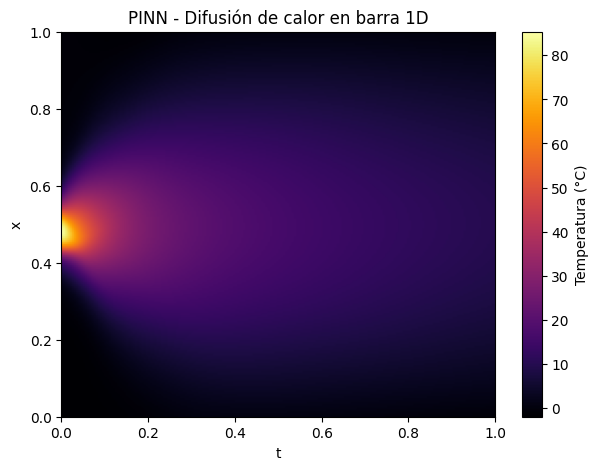

In [8]:
# --- gráfico heatmap ---
plt.figure(figsize=(7, 5))
plt.imshow(U_pred, extent=[0, 1, 0, 1], origin="lower", aspect="auto", cmap="inferno")
plt.colorbar(label="Temperatura (°C)")
plt.xlabel("t")
plt.ylabel("x")
plt.title("PINN - Difusión de calor en barra 1D")
plt.show()


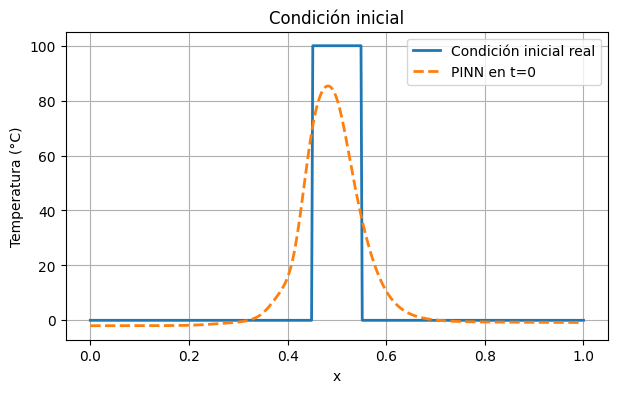

In [9]:
# --- perfil inicial aprendido vs condición inicial real ---
x_ic = torch.linspace(0, 1, 400).view(-1, 1).to(device)
t_ic = torch.zeros_like(x_ic)

ui_real = torch.where(
    ((x_ic >= 0.45) & (x_ic <= 0.55)),
    torch.tensor(100.0, device=device),
    torch.tensor(0.0, device=device)
)

with torch.no_grad():
    ui_pred = model(x_ic, t_ic).cpu().numpy()
    ui_real = ui_real.cpu().numpy()
    x_ic = x_ic.cpu().numpy()

plt.figure(figsize=(7, 4))
plt.plot(x_ic, ui_real, label="Condición inicial real", linewidth=2)
plt.plot(x_ic, ui_pred, "--", label="PINN en t=0", linewidth=2)
plt.xlabel("x")
plt.ylabel("Temperatura (°C)")
plt.title("Condición inicial")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# --- Solución analítica por serie de Fourier


x_np = x.cpu().numpy().flatten()   # 200 puntos en x
t_np = t.cpu().numpy().flatten()   # 200 puntos en t

Nx = len(x_np)
Nt = len(t_np)

U_exact = np.zeros((Nx, Nt))

# número de términos de la serie
N_terms = 200

for n in range(1, N_terms + 1):
    bn = (200.0 / (n * np.pi)) * (
        np.cos(n * np.pi * 0.45) - np.cos(n * np.pi * 0.55)
    )

    spatial = np.sin(n * np.pi * x_np)[:, None]                 # (Nx, 1)
    temporal = np.exp(-alpha * (n * np.pi)**2 * t_np)[None, :] # (1, Nt)

    U_exact += bn * spatial * temporal

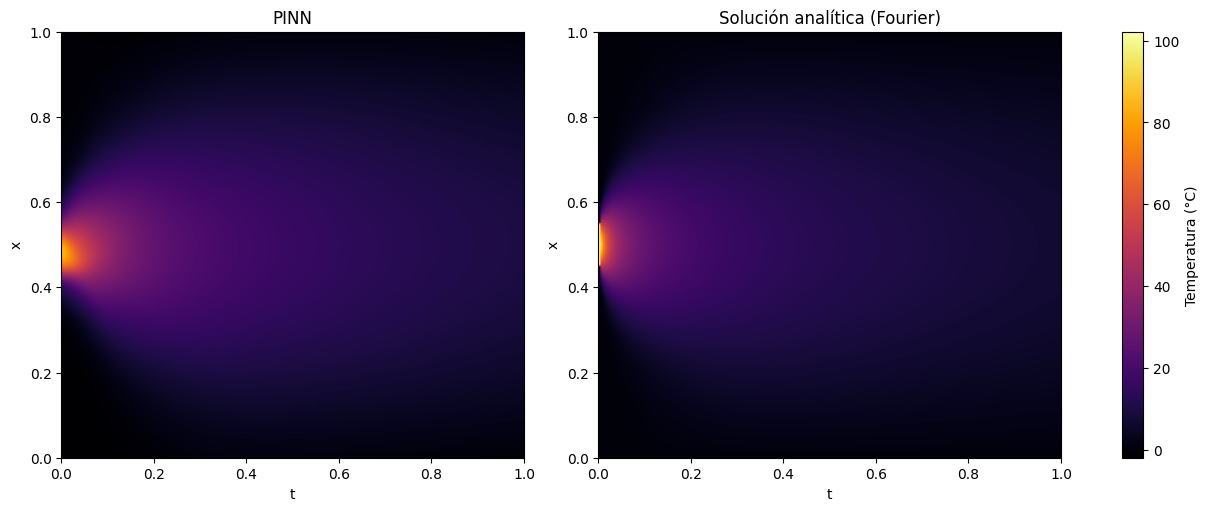

In [12]:
# --- Comparación ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

vmin = min(U_pred.min(), U_exact.min())
vmax = max(U_pred.max(), U_exact.max())

im1 = axes[0].imshow(
    U_pred,
    extent=[0, 1, 0, 1],
    origin="lower",
    aspect="auto",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title("PINN")
axes[0].set_xlabel("t")
axes[0].set_ylabel("x")

im2 = axes[1].imshow(
    U_exact,
    extent=[0, 1, 0, 1],
    origin="lower",
    aspect="auto",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("Solución analítica (Fourier)")
axes[1].set_xlabel("t")
axes[1].set_ylabel("x")

fig.colorbar(im2, ax=axes, label="Temperatura (°C)")
plt.show()